In [1]:
from nrs import EType, NRS_Model, Element, NRS_Revision, NRS_Observer_E    # классы НРС
from nrs import NRS_Data as nd                                      # Табличные данные НРС
from nrs import q_out_simple, q_out_nozzle                          # модели расчета параметров
import matplotlib.pyplot as plt                                     # библиотеки для отрисовки получаемых данных

2 рукава 51, разветвление + 2 рабочих линии по 1 рукаву 51 + РСКУ-50А

# Анализ экспериментальных данных

In [64]:
# Вычисляем проводимости гладкоствольных насадков для стволов Б (13мм) и А (19мм)
p_2 = NRS_Revision.calc_p(2, 40)
p_4 = NRS_Revision.calc_p(4, 40)
p_6 = NRS_Revision.calc_p(6, 40)
p_8 = NRS_Revision.calc_p(8, 40)
p_2, p_4, p_6, p_8

(0.31622776601683794,
 0.6324555320336759,
 0.9486832980505138,
 1.2649110640673518)

In [65]:
# Сопротивление одного рукава 51 мм, эмпирическое:
ss51 = 0.09

# Создаем модель НРС:
model = NRS_Model('Модель от одного насоса к двум стволам через одно разветвление')

# Создаем элементы модели:
pump = Element('Н1', 0, H_add=10)                                       # Насос
hoseM_1 = Element('МРЛ Н-Р1', 1, s=ss51, n=3)                    # магистральная рукавная линия №1 - от насоса к разветвлению №1

splitter_1 = Element('Р1', 1, ro = 3)                                           # разветвление №1
hoseW_11 = Element('РРЛ Р1-1', 1, s = ss51, n=1)                   # рабочая рукавная линия от разветвления №1 к стволу №1
nozzle_11 = Element('Ствол 1', 2, p = p_2, q_out = q_out_nozzle)          # ствол №1 (положение 2 л/с)
hoseW_12 = Element('РРЛ Р1-2', 1, s = ss51, n=1)                   # рабочая рукавная линия от разветвления №1 к стволу №2
nozzle_12 = Element('Ствол 2', 2, p = p_8, q_out = q_out_nozzle)          # ствол №2 (положение 8 л/с)

# Соединяем элементы модели вместе в НРС:
# Магистральная часть:
pump.append(hoseM_1).append(splitter_1)

splitter_1.append(hoseW_11).append(nozzle_11)   # Рукавная линия от разветвления №1 к стволу №1
splitter_1.append(hoseW_12).append(nozzle_12)   # Рукавная линия от разветвления №1 к стволу №2


# Строим модель:
model = model.build(pump, interpretate=True)

In [66]:
NRS_Revision.print_model_elements(model)

Модель от одного насоса к двум стволам через одно разветвление
all:
  Н1
  МРЛ Н-Р1
  Р1
  РРЛ Р1-1
  Ствол 1
  РРЛ Р1-2
  Ствол 2
in:
  Н1
out:
  Ствол 1
  Ствол 2


### Эксперимент 1

- Ствол 1 - положение 2 л/с
- Ствол 2 - положение 8 л/с

In [67]:
# Насос
h_pump = []
q_pump = []
# Ствол 1
h_n1   = []
q_n1   = []
# Ствол 2
h_n2   = []
q_n2   = []

# Моделирование:
for h in range (10, 100):
    
    # Шаг моделирования
    model.drop_q()
    # Напор на насосе
    pump.set_H_add(h)
    model, r = model.calc(accuracy=0.05)

    # Запоминаем результат
    h_pump.append(h)
    q_pump.append(pump.q)
    h_n1.append(nozzle_11.H_in)
    q_n1.append(nozzle_11.q)
    h_n2.append(nozzle_12.H_in)
    q_n2.append(nozzle_12.q)


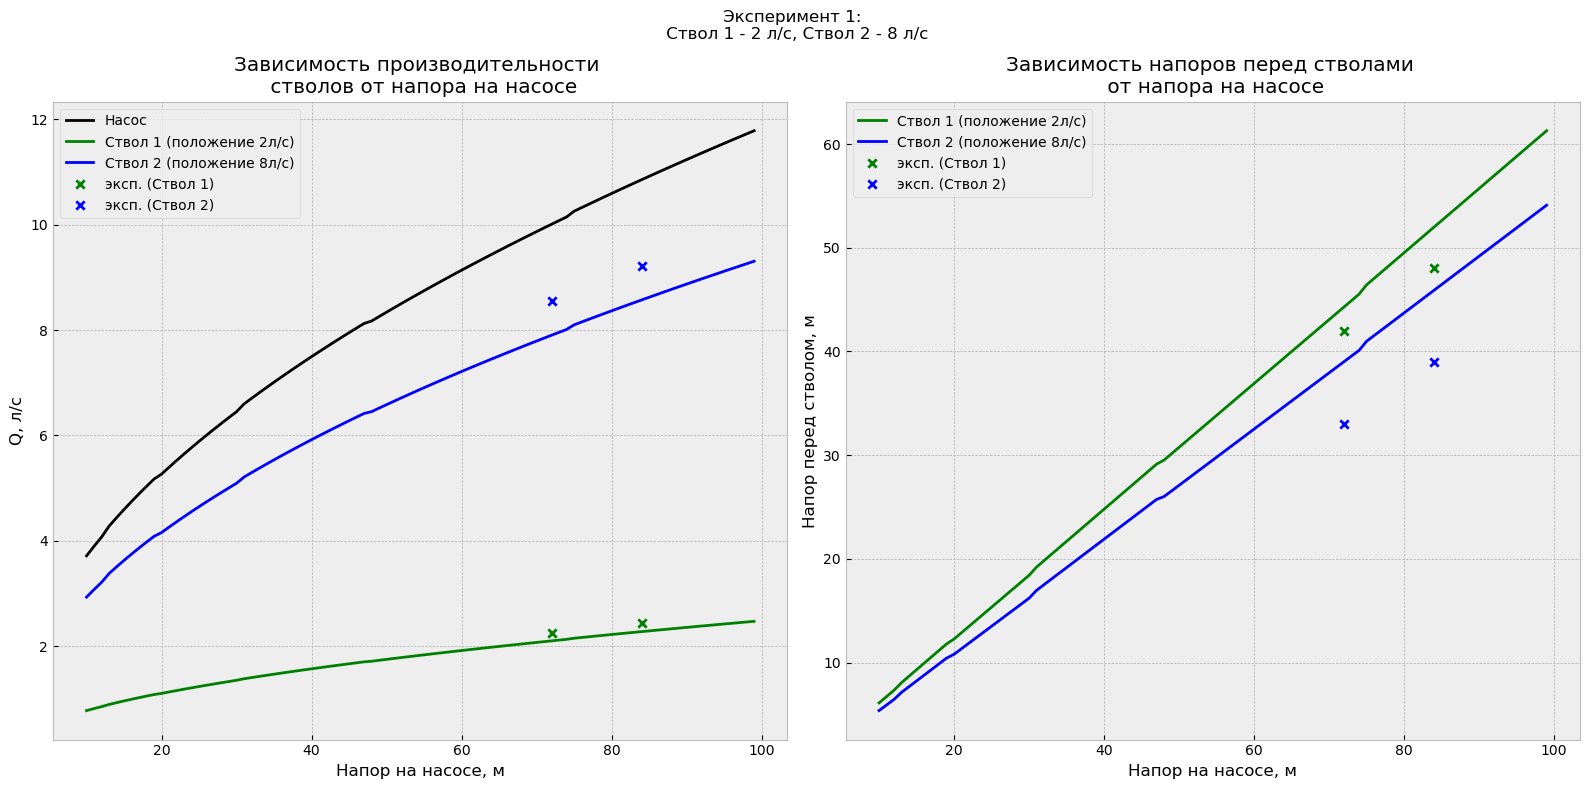

In [68]:
plt.style.use('bmh')

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(16,8))

ax1.plot(h_pump, q_pump, c='k', label='Насос')
ax1.plot(h_pump, q_n1, c='g', label='Ствол 1 (положение 2л/с)')
ax1.plot(h_pump, q_n2, c='b', label='Ствол 2 (положение 8л/с)')
ax1.scatter([72, 84], [2.26, 2.44], marker='x', c='g', label='эксп. (Ствол 1)')
ax1.scatter([72, 84], [8.55, 9.22], marker='x', c='b', label='эксп. (Ствол 2)')
ax1.set_xlabel('Напор на насосе, м')
ax1.set_ylabel('Q, л/с')
ax1.legend()
ax1.set_title('Зависимость производительности \n стволов от напора на насосе')

ax2.plot(h_pump, h_n1, c='g', label='Ствол 1 (положение 2л/с)')
ax2.plot(h_pump, h_n2, c='b', label='Ствол 2 (положение 8л/с)')
ax2.scatter([72, 84], [42, 48], marker='x', c='g', label='эксп. (Ствол 1)')
ax2.scatter([72, 84], [33, 39], marker='x', c='b', label='эксп. (Ствол 2)')
ax2.set_xlabel('Напор на насосе, м')
ax2.set_ylabel('Напор перед стволом, м')
ax2.set_title('Зависимость напоров перед стволами \n от напора на насосе')
ax2.legend()

fig.suptitle('Эксперимент 1: \n Ствол 1 - 2 л/с, Ствол 2 - 8 л/с')
fig.tight_layout()
plt.show()

In [75]:
from statistics import mean


стартовый_напор = 10
напор11 = 72
напор12 = 84
напор21 = 72
напор22 = 84

расход11 = 2.26
расход12 = 2.44
расход21 = 8.55
расход22 = 9.22


err1 = abs(q_n1[напор11-стартовый_напор] - расход11) / q_n1[напор11-стартовый_напор]
err2 = abs(q_n1[напор12-стартовый_напор] - расход12) / q_n1[напор12-стартовый_напор]
err3 = abs(q_n2[напор21-стартовый_напор] - расход21) / q_n2[напор21-стартовый_напор]
err4 = abs(q_n2[напор22-стартовый_напор] - расход22) / q_n2[напор22-стартовый_напор]
print('Средняя ошибка:', round(mean([err1, err2, err3, err4])*100, 2), '%')

Средняя ошибка: 7.54 %


### Эксперимент 2

- Ствол 1 - положение 4 л/с
- Ствол 2 - положение 8 л/с

In [9]:
# Предварительная настройка модели

# Сброс состояния
model.drop_q()

# Расчет НРС с новыми параметрами:
pump.set_H_add(10)
nozzle_11.p = p_4
model, r = model.calc(accuracy=0.05)

ValueError: Напор не может быть выше 120

In [ ]:
# Насос
h_pump = []
q_pump = []
# Ствол 1
h_n1   = []
q_n1   = []
# Ствол 2
h_n2   = []
q_n2   = []

# Моделирование:
for h in range (10, 100):
    
    # Шаг моделирования
    model.drop_q()
    # Напор на насосе
    pump.set_H_add(h)
    model, r = model.calc(accuracy=0.05)

    # Запоминаем результат
    h_pump.append(h)
    q_pump.append(pump.q)
    h_n1.append(nozzle_11.H_in)
    q_n1.append(nozzle_11.q)
    h_n2.append(nozzle_12.H_in)
    q_n2.append(nozzle_12.q)

In [ ]:
plt.style.use('bmh')

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(16,8))

ax1.plot(h_pump, q_pump, c='k', label='Насос')
ax1.plot(h_pump, q_n1, c='g', label='Ствол 1 (положение 4л/с)')
ax1.plot(h_pump, q_n2, c='b', label='Ствол 2 (положение 8л/с)')
ax1.scatter([83], [3.86], marker='x', c='g', label='эксп. (Ствол 1)')
ax1.scatter([83], [8.58], marker='x', c='b', label='эксп. (Ствол 2)')
ax1.set_xlabel('Напор на насосе, м')
ax1.set_ylabel('Q, л/с')
ax1.legend()
ax1.set_title('Зависимость производительности \n стволов от напора на насосе')

ax2.plot(h_pump, h_n1, c='g', label='Ствол 1 (положение 4л/с)')
ax2.plot(h_pump, h_n2, c='b', label='Ствол 2 (положение 8л/с)')
ax2.scatter([83], [41], marker='x', c='g', label='эксп. (Ствол 1)')
ax2.scatter([83], [34], marker='x', c='b', label='эксп. (Ствол 2)')
ax2.set_xlabel('Напор на насосе, м')
ax2.set_ylabel('Напор перед стволом, м')
ax2.set_title('Зависимость напоров перед стволами \n от напора на насосе')
ax2.legend()

fig.suptitle('Эксперимент 2: \n Ствол 1 - 4 л/с, Ствол 2 - 8 л/с')
fig.tight_layout()
plt.show()

### Эксперимент 3

- Ствол 1 - положение 8 л/с
- Ствол 2 - положение 8 л/с

In [10]:
# Предварительная настройка модели

# Сброс состояния
model.drop_q()

# Расчет НРС с новыми параметрами:
pump.set_H_add(10)
nozzle_11.p = p_8
model, r = model.calc(accuracy=0.05)

ValueError: Напор не может быть выше 120

In [ ]:
# Насос
h_pump = []
q_pump = []
# Ствол 1
h_n1   = []
q_n1   = []
# Ствол 2
h_n2   = []
q_n2   = []

# Моделирование:
for h in range (10, 100):
    
    # Шаг моделирования
    model.drop_q()
    # Напор на насосе
    pump.set_H_add(h)
    model, r = model.calc(accuracy=0.05)

    # Запоминаем результат
    h_pump.append(h)
    q_pump.append(pump.q)
    h_n1.append(nozzle_11.H_in)
    q_n1.append(nozzle_11.q)
    h_n2.append(nozzle_12.H_in)
    q_n2.append(nozzle_12.q)

In [ ]:
plt.style.use('bmh')

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(16,8))

ax1.plot(h_pump, q_pump, c='k', label='Насос')
ax1.plot(h_pump, q_n1, c='g', label='Ствол 1 (положение 8л/с)')
ax1.plot(h_pump, q_n2, c='b', label='Ствол 2 (положение 8л/с)')
ax1.scatter([82, 99], [6.58, 7.3], marker='x', c='g', label='эксп. (Ствол 1)')
ax1.scatter([82, 99], [7.33, 8.16], marker='x', c='b', label='эксп. (Ствол 2)')
ax1.set_xlabel('Напор на насосе, м')
ax1.set_ylabel('Q, л/с')
ax1.legend()
ax1.set_title('Зависимость производительности \n стволов от напора на насосе')

ax2.plot(h_pump, h_n1, c='g', label='Ствол 1 (положение 8л/с)')
ax2.plot(h_pump, h_n2, c='b', label='Ствол 2 (положение 8л/с)')
ax2.scatter([82, 99], [27, 33], marker='x', c='g', label='эксп. (Ствол 1)')
ax2.scatter([82, 99], [25, 31], marker='x', c='b', label='эксп. (Ствол 2)')
ax2.set_xlabel('Напор на насосе, м')
ax2.set_ylabel('Напор перед стволом, м')
ax2.set_title('Зависимость напоров перед стволами \n от напора на насосе')
ax2.legend()

fig.suptitle('Эксперимент 3: \n Ствол 1 - 8 л/с, Ствол 2 - 8 л/с')
fig.tight_layout()
plt.show()

### Эксперимент 4

- Ствол 1 - положение 0 л/с
- Ствол 2 - положение 8 л/с

In [11]:
# Предварительная настройка модели

# Сброс состояния
model.drop_q()

# Расчет НРС с новыми параметрами:
pump.set_H_add(10)
nozzle_11.p = 0
model, r = model.calc(accuracy=0.05)

In [12]:
# Насос
h_pump = []
q_pump = []
# Ствол 1
h_n1   = []
q_n1   = []
# Ствол 2
h_n2   = []
q_n2   = []

# Моделирование:
for h in range (10, 110):
    
    # Шаг моделирования
    model.drop_q()
    # Напор на насосе
    pump.set_H_add(h)
    model, r = model.calc(accuracy=0.05)

    # Запоминаем результат
    h_pump.append(h)
    q_pump.append(pump.q)
    h_n1.append(nozzle_11.H_in)
    q_n1.append(nozzle_11.q)
    h_n2.append(nozzle_12.H_in)
    q_n2.append(nozzle_12.q)

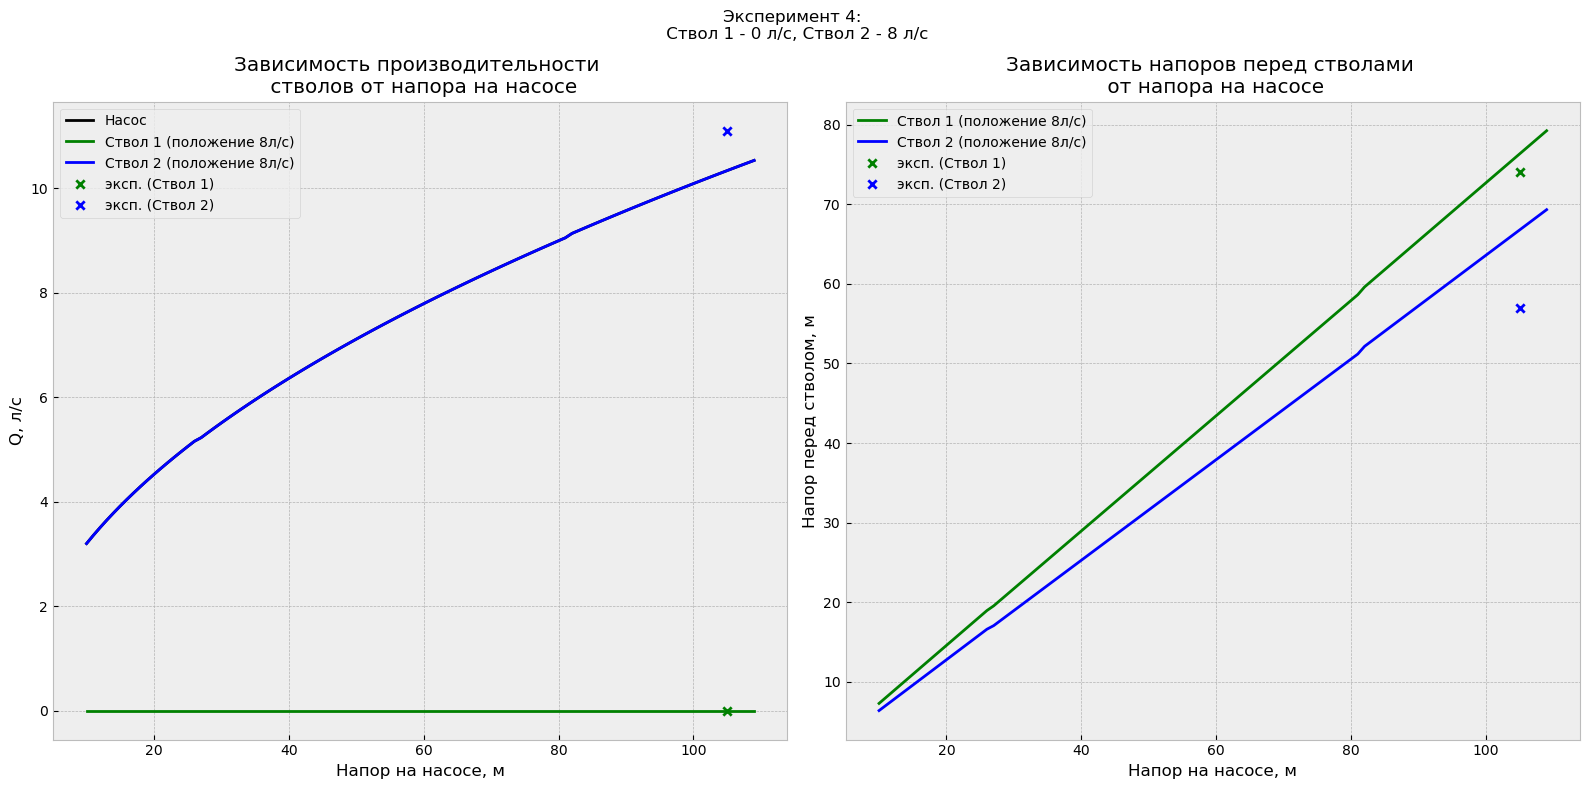

In [13]:
plt.style.use('bmh')

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(16,8))

ax1.plot(h_pump, q_pump, c='k', label='Насос')
ax1.plot(h_pump, q_n1, c='g', label='Ствол 1 (положение 8л/с)')
ax1.plot(h_pump, q_n2, c='b', label='Ствол 2 (положение 8л/с)')
ax1.scatter([105], [0], marker='x', c='g', label='эксп. (Ствол 1)')
ax1.scatter([105], [11.1], marker='x', c='b', label='эксп. (Ствол 2)')
ax1.set_xlabel('Напор на насосе, м')
ax1.set_ylabel('Q, л/с')
ax1.legend()
ax1.set_title('Зависимость производительности \n стволов от напора на насосе')

ax2.plot(h_pump, h_n1, c='g', label='Ствол 1 (положение 8л/с)')
ax2.plot(h_pump, h_n2, c='b', label='Ствол 2 (положение 8л/с)')
ax2.scatter([105], [74], marker='x', c='g', label='эксп. (Ствол 1)')
ax2.scatter([105], [57], marker='x', c='b', label='эксп. (Ствол 2)')
ax2.set_xlabel('Напор на насосе, м')
ax2.set_ylabel('Напор перед стволом, м')
ax2.set_title('Зависимость напоров перед стволами \n от напора на насосе')
ax2.legend()

fig.suptitle('Эксперимент 4: \n Ствол 1 - 0 л/с, Ствол 2 - 8 л/с')
fig.tight_layout()
plt.show()

# Анализ на основе уточненных значений проводимости

In [2]:
p_2 = NRS_Revision.calc_p(2.16, 40)
p_4 = NRS_Revision.calc_p(4.85, 40)
p_6 = NRS_Revision.calc_p(6, 40)
p_8 = NRS_Revision.calc_p(8.61, 40)

In [19]:
# Сопротивление одного рукава 51 мм, эмпирическое:
ss51 = 0.085

# Создаем модель НРС:
model = NRS_Model('Модель от одного насоса к двум стволам через одно разветвление с добавленными сопротивлениями в РТ-80')

# Создаем элементы модели:
pump = Element('Н1', EType.PUMP, H_add=10)                                       # Насос
hoseM_1 = Element('МРЛ Н-Р1', EType.CONNECTOR, s=ss51, n=3)                    # магистральная рукавная линия №1 - от насоса к разветвлению №1

splitter_1 = Element('Р1', EType.CONNECTOR, s = 0.067, ro = 3)                                           # разветвление №1
hoseW_11 = Element('РРЛ Р1-1', EType.CONNECTOR, s = ss51, n=1)                   # рабочая рукавная линия от разветвления №1 к стволу №1
nozzle_11 = Element('Ствол 1', EType.NOZZLE, p = p_2, q_out = q_out_nozzle)          # ствол №1 (положение 2 л/с)
hoseW_12 = Element('РРЛ Р1-2', EType.CONNECTOR, s = ss51, n=1)                   # рабочая рукавная линия от разветвления №1 к стволу №2
nozzle_12 = Element('Ствол 2', EType.NOZZLE, p = p_8, q_out = q_out_nozzle)          # ствол №2 (положение 8 л/с)

# resistance_left = Element('Сопротивление левое', EType.CONNECTOR, s = 0.067, n=1)
# resistance_right = Element('Сопротивление правое', EType.CONNECTOR, s = 0.067, n=1)

# Соединяем элементы модели вместе в НРС:
# Магистральная часть:
pump.append(hoseM_1).append(splitter_1)

splitter_1.append(hoseW_11).append(nozzle_11)   # Рукавная линия от разветвления №1 к стволу №1
splitter_1.append(hoseW_12).append(nozzle_12)   # Рукавная линия от разветвления №1 к стволу №2


# Строим модель:
model = model.build(pump, interpretate=True)

NRS_Revision.print_model_elements(model)

Модель от одного насоса к двум стволам через одно разветвление с добавленными сопротивлениями в РТ-80
all:
  Н1
  МРЛ Н-Р1
  Р1
  РРЛ Р1-1
  Ствол 1
  РРЛ Р1-2
  Ствол 2
in:
  Н1
out:
  Ствол 1
  Ствол 2


### Эксперимент 1

In [22]:
# Насос
h_pump = []
q_pump = []
# Ствол 1
h_n1   = []
q_n1   = []
# Ствол 2
h_n2   = []
q_n2   = []

# Моделирование:
for h in range (10, 100):
    print(h, end='\r')
    
    # Шаг моделирования
    model.drop_q()
    # Напор на насосе
    pump.set_H_add(h)
    try:
        model, r = model.calc(accuracy=0.05)
    except:
        pass

    # Запоминаем результат
    h_pump.append(h)
    q_pump.append(pump.q)
    h_n1.append(nozzle_11.H_in)
    q_n1.append(nozzle_11.q)
    h_n2.append(nozzle_12.H_in)
    q_n2.append(nozzle_12.q)


c:\ProgramData\Anaconda3\lib\site-packages\numpy\core\_asarray.py:102: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


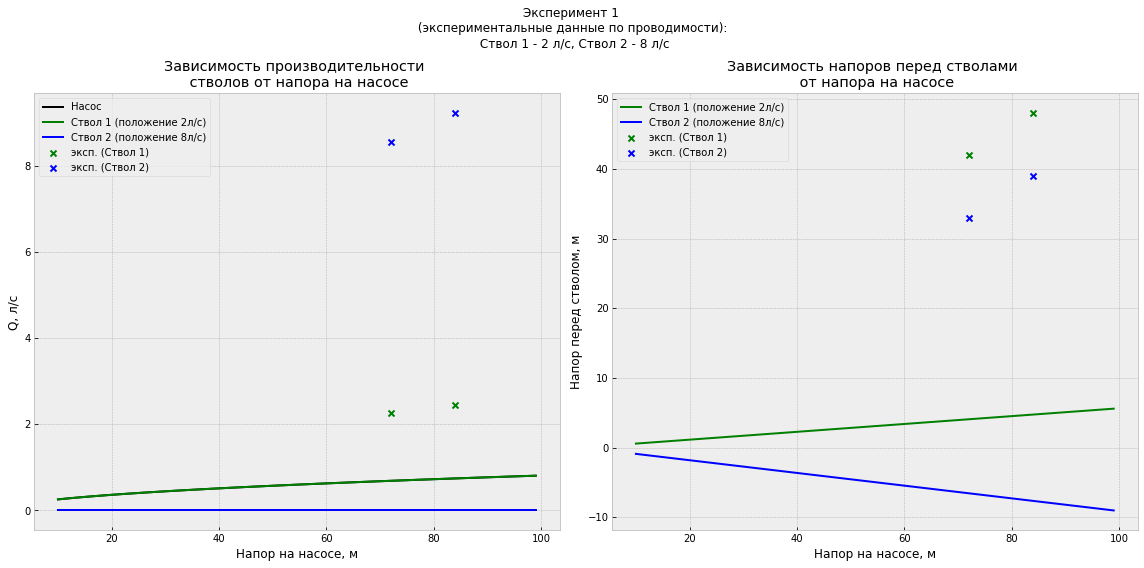

In [23]:
plt.style.use('bmh')

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(16,8))

top = 90

ax1.plot(h_pump[:top], q_pump[:top], c='k', label='Насос')
ax1.plot(h_pump[:top], q_n1[:top], c='g', label='Ствол 1 (положение 2л/с)')
ax1.plot(h_pump[:top], q_n2[:top], c='b', label='Ствол 2 (положение 8л/с)')
ax1.scatter([72, 84], [2.26, 2.44], marker='x', c='g', label='эксп. (Ствол 1)')
ax1.scatter([72, 84], [8.55, 9.22], marker='x', c='b', label='эксп. (Ствол 2)')
ax1.set_xlabel('Напор на насосе, м')
ax1.set_ylabel('Q, л/с')
ax1.legend()
ax1.set_title('Зависимость производительности \n стволов от напора на насосе')

ax2.plot(h_pump[:top], h_n1[:top], c='g', label='Ствол 1 (положение 2л/с)')
ax2.plot(h_pump[:top], h_n2[:top], c='b', label='Ствол 2 (положение 8л/с)')
ax2.scatter([72, 84], [42, 48], marker='x', c='g', label='эксп. (Ствол 1)')
ax2.scatter([72, 84], [33, 39], marker='x', c='b', label='эксп. (Ствол 2)')
ax2.set_xlabel('Напор на насосе, м')
ax2.set_ylabel('Напор перед стволом, м')
ax2.set_title('Зависимость напоров перед стволами \n от напора на насосе')
ax2.legend()

fig.suptitle('Эксперимент 1 \n (экспериментальные данные по проводимости): \n Ствол 1 - 2 л/с, Ствол 2 - 8 л/с')
fig.tight_layout()
plt.show()

In [8]:
from statistics import mean


стартовый_напор = 10
напор11 = 72
напор12 = 84
напор21 = 72
напор22 = 84

расход11 = 2.26
расход12 = 2.44
расход21 = 8.55
расход22 = 9.22


err1 = abs(q_n1[напор11-стартовый_напор] - расход11) / q_n1[напор11-стартовый_напор]
err2 = abs(q_n1[напор12-стартовый_напор] - расход12) / q_n1[напор12-стартовый_напор]
err3 = abs(q_n2[напор21-стартовый_напор] - расход21) / q_n2[напор21-стартовый_напор]
err4 = abs(q_n2[напор22-стартовый_напор] - расход22) / q_n2[напор22-стартовый_напор]
print('Средняя ошибка:', round(mean([err1, err2, err3, err4])*100, 2), '%')

Средняя ошибка: 3.01 %


### Эксперимент 4

In [16]:
# Предварительная настройка модели

# Сброс состояния
model.drop_q()

# Расчет НРС с новыми параметрами:
pump.set_H_add(10)
nozzle_11.p = 0
model, r = model.calc(accuracy=0.05)

In [17]:
# Насос
h_pump = []
q_pump = []
# Ствол 1
h_n1   = []
q_n1   = []
# Ствол 2
h_n2   = []
q_n2   = []

# Моделирование:
for h in range (10, 110):
    
    # Шаг моделирования
    model.drop_q()
    # Напор на насосе
    pump.set_H_add(h)
    model, r = model.calc(accuracy=0.05)

    # Запоминаем результат
    h_pump.append(h)
    q_pump.append(pump.q)
    h_n1.append(nozzle_11.H_in)
    q_n1.append(nozzle_11.q)
    h_n2.append(nozzle_12.H_in)
    q_n2.append(nozzle_12.q)

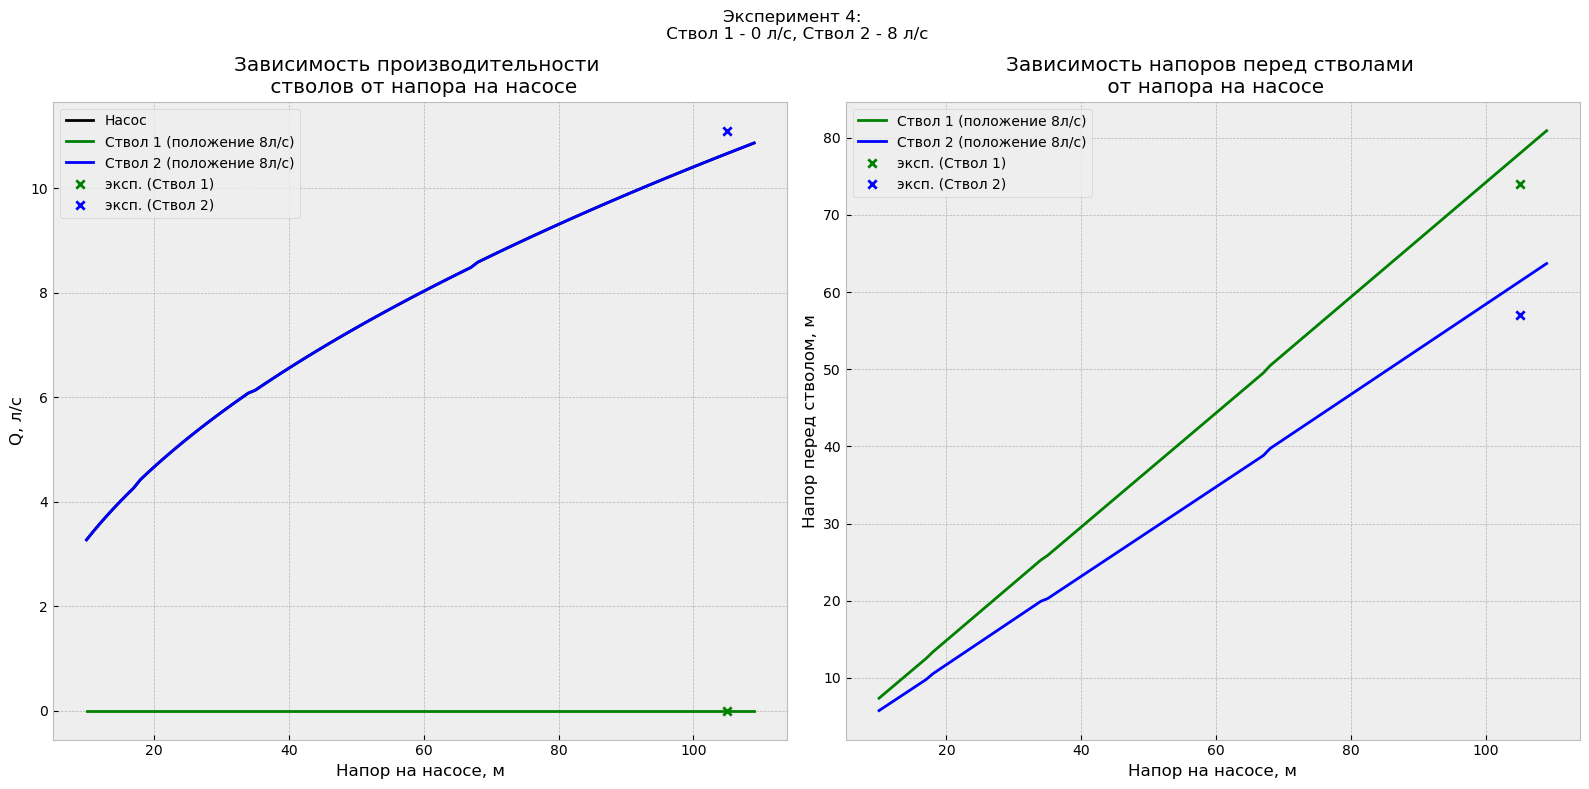

In [18]:
plt.style.use('bmh')

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(16,8))

ax1.plot(h_pump, q_pump, c='k', label='Насос')
ax1.plot(h_pump, q_n1, c='g', label='Ствол 1 (положение 8л/с)')
ax1.plot(h_pump, q_n2, c='b', label='Ствол 2 (положение 8л/с)')
ax1.scatter([105], [0], marker='x', c='g', label='эксп. (Ствол 1)')
ax1.scatter([105], [11.1], marker='x', c='b', label='эксп. (Ствол 2)')
ax1.set_xlabel('Напор на насосе, м')
ax1.set_ylabel('Q, л/с')
ax1.legend()
ax1.set_title('Зависимость производительности \n стволов от напора на насосе')

ax2.plot(h_pump, h_n1, c='g', label='Ствол 1 (положение 8л/с)')
ax2.plot(h_pump, h_n2, c='b', label='Ствол 2 (положение 8л/с)')
ax2.scatter([105], [74], marker='x', c='g', label='эксп. (Ствол 1)')
ax2.scatter([105], [57], marker='x', c='b', label='эксп. (Ствол 2)')
ax2.set_xlabel('Напор на насосе, м')
ax2.set_ylabel('Напор перед стволом, м')
ax2.set_title('Зависимость напоров перед стволами \n от напора на насосе')
ax2.legend()

fig.suptitle('Эксперимент 4: \n Ствол 1 - 0 л/с, Ствол 2 - 8 л/с')
fig.tight_layout()
plt.show()